In [1]:
!pip -q install librosa soundfile noisereduce scikit-learn xgboost tqdm kagglehub openai-whisper groq joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 12.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 5.7 MB/s eta 0:00:00


In [2]:
import os
import re
import glob
import json
import pickle
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display
import soundfile as sf
import noisereduce as nr

from tqdm import tqdm

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from google.colab import drive
from google.colab import files

warnings.filterwarnings("ignore")
np.random.seed(42)

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATASET_PATH = "/content/drive/MyDrive/audio_speech_actors_01-24"

MODEL_DIR = "/content/drive/MyDrive/Emotion_Recognition_Model"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "emotion_svm_model.pkl")
LABEL_ENCODER_PATH = os.path.join(MODEL_DIR, "label_encoder.pkl")

print("Dataset path:", DATASET_PATH)
print("Model folder:", MODEL_DIR)

Dataset path: /content/drive/MyDrive/audio_speech_actors_01-24
Model folder: /content/drive/MyDrive/Emotion_Recognition_Model


In [5]:
SAMPLE_RATE = 22050
DURATION = 3.5
OFFSET = 0.4

N_MFCC = 40
N_CHROMA = 12
N_MEL = 40
N_CONTRAST = 7

WINDOW_DURATION = 3.5
WINDOW_OVERLAP = 0.5
RMS_SILENCE_THRESHOLD = 0.01

RANDOM_STATE = 42

SVM_HIGH_CONFIDENCE_THRESHOLD = 0.80
ACOUSTIC_WEIGHT = 0.65
LLM_WEIGHT = 0.35

EMOTION_LABELS = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

print("Configuration loaded.")

Configuration loaded.


In [6]:
def load_audio(file_path, sr=SAMPLE_RATE, duration=None, offset=0.0):
    audio, sr = librosa.load(file_path, sr=sr, duration=duration, offset=offset)
    return audio, sr

In [7]:
def add_noise(audio, noise_factor=0.005):
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

In [8]:
def pitch_shift(audio, sr, n_steps):
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)

In [9]:
def time_stretch(audio, rate):
    return librosa.effects.time_stretch(audio, rate=rate)

In [10]:
def extract_features(audio, sr):

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr, n_chroma=N_CHROMA)
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MEL)
    mel_db = librosa.power_to_db(mel)
    contrast = librosa.feature.spectral_contrast(y=audio, sr=sr, n_bands=N_CONTRAST - 1)
    harmonic = librosa.effects.harmonic(audio)
    tonnetz = librosa.feature.tonnetz(y=harmonic, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(audio)
    rms = librosa.feature.rms(y=audio)

    blocks = [mfcc, chroma, mel_db, contrast, tonnetz, zcr, rms]

    feature_vector = np.concatenate(
        [np.mean(b, axis=1) for b in blocks] + [np.std(b, axis=1) for b in blocks]
    )

    return feature_vector

In [11]:
X_CACHE = os.path.join(MODEL_DIR, "X.npy")
Y_CACHE = os.path.join(MODEL_DIR, "y.npy")

if os.path.exists(X_CACHE) and os.path.exists(Y_CACHE):
    print("Loading cached features...")

    X = np.load(X_CACHE)
    y = np.load(Y_CACHE)

else:
    print("Cached features not found. Building feature dataset...")

    audio_files = glob.glob(
        os.path.join(DATASET_PATH, "**", "Actor_*", "*.wav"),
        recursive=True
    )

    print(f"Found {len(audio_files)} audio files")

    X = []
    y = []

    original_count = 0
    noise_count = 0
    pitch_count = 0

    for file in tqdm(audio_files):
        emotion_code = os.path.basename(file).split("-")[2]
        if emotion_code not in emotion_map:
            continue

        label = emotion_map[emotion_code]
        try:
            audio, sr = load_audio(
                file,
                duration=DURATION,
                offset=OFFSET
            )

            X.append(extract_features(audio, sr))
            y.append(label)
            original_count += 1

            X.append(extract_features(add_noise(audio), sr))
            y.append(label)
            noise_count += 1

            shifted = pitch_shift(
                audio,
                sr,
                n_steps=np.random.uniform(-2, 2)
            )

            X.append(extract_features(shifted, sr))
            y.append(label)
            pitch_count += 1

        except Exception as e:
            print(f"Error processing {os.path.basename(file)}: {e}")
            continue

    X = np.array(X)
    y = np.array(y)

    np.save(X_CACHE, X)
    np.save(Y_CACHE, y)

    print("Features cached successfully.")

    print("\n----- Sample Counts -----")
    print(f"Original      : {original_count}")
    print(f"Noise         : {noise_count}")
    print(f"Pitch Shift   : {pitch_count}")
    print(f"Total Samples : {original_count + noise_count + pitch_count}")

print("X shape:", X.shape)
print("y shape:", y.shape)

Loading cached features...
X shape: (4320, 214)
y shape: (4320,)


In [12]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

pickle.dump(label_encoder, open(LABEL_ENCODER_PATH, "wb"))

print(list(label_encoder.classes_))

[np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(3456, 214)
(864, 214)


In [14]:
param_distributions = {
    "svm__C": [1, 5, 10, 20, 50],
    "svm__gamma": ["scale", "auto", 0.001, 0.01],
    "svm__kernel": ["rbf"]
}

base_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE))
])

search = RandomizedSearchCV(
    base_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=3,
    scoring="accuracy",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

pipeline = search.best_estimator_
print("Best params:", search.best_params_)
print("Best CV accuracy:", search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'svm__kernel': 'rbf', 'svm__gamma': 0.01, 'svm__C': 20}
Best CV accuracy: 0.7057291666666666


In [15]:
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {accuracy:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Test accuracy: 0.7870

              precision    recall  f1-score   support

       angry       0.84      0.84      0.84       115
        calm       0.73      0.88      0.80       115
     disgust       0.76      0.84      0.80       115
     fearful       0.82      0.77      0.80       115
       happy       0.79      0.73      0.76       115
     neutral       0.71      0.55      0.62        58
         sad       0.74      0.68      0.71       115
   surprised       0.88      0.88      0.88       116

    accuracy                           0.79       864
   macro avg       0.78      0.77      0.77       864
weighted avg       0.79      0.79      0.79       864



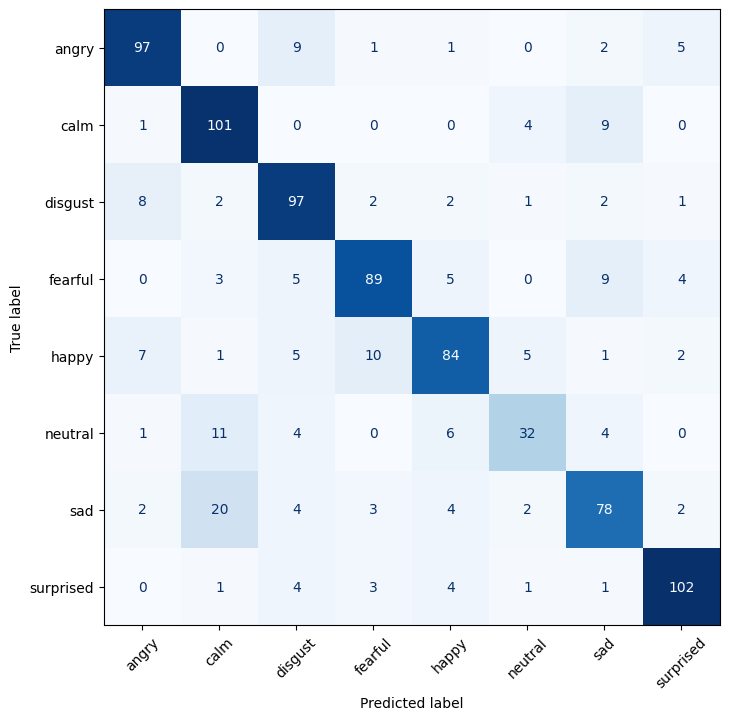

In [16]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.xticks(rotation=45)
plt.show()

In [17]:
with open(MODEL_PATH, "wb") as f:
    pickle.dump(pipeline, f)

print("Model saved to:", MODEL_PATH)

Model saved to: /content/drive/MyDrive/Emotion_Recognition_Model/emotion_svm_model.pkl


In [18]:
with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

with open(LABEL_ENCODER_PATH, "rb") as f:
    label_encoder = pickle.load(f)

print("Model and label encoder loaded.")

Model and label encoder loaded.


In [19]:
def predict_window(window, sr):

    features = extract_features(window, sr).reshape(1, -1)
    probabilities = model.predict_proba(features)[0]
    predicted_index = np.argmax(probabilities)
    predicted_emotion = label_encoder.inverse_transform([predicted_index])[0]
    confidence = probabilities[predicted_index]

    return predicted_emotion, confidence, probabilities

In [20]:
def predict_audio_acoustic(audio_path):

    audio, sr = librosa.load(audio_path, sr=SAMPLE_RATE)

    window_size = int(WINDOW_DURATION * sr)
    hop_size = int(window_size * (1 - WINDOW_OVERLAP))

    if len(audio) < window_size:
        audio = np.pad(audio, (0, window_size - len(audio)))

    probability_vectors = []
    window_predictions = []

    for start in range(
        0,
        max(len(audio) - window_size, 0) + 1,
        hop_size
    ):

        window = audio[start:start + window_size]

        rms = np.sqrt(np.mean(window ** 2))

        if rms < RMS_SILENCE_THRESHOLD:
            continue

        emotion, confidence, probabilities = predict_window(window, sr)

        probability_vectors.append(probabilities)
        window_predictions.append((emotion, confidence))

    if not probability_vectors:
        return "neutral", 0.0, []

    mean_probabilities = np.mean(probability_vectors, axis=0)

    predicted_index = np.argmax(mean_probabilities)

    final_emotion = label_encoder.inverse_transform([predicted_index])[0]
    final_confidence = float(mean_probabilities[predicted_index])

    return final_emotion, final_confidence, window_predictions

In [21]:
import whisper

whisper_model = whisper.load_model("base")
print("Whisper model loaded.")

100%|███████████████████████████████████████| 139M/139M [00:02<00:00, 61.5MiB/s]


Whisper model loaded.


In [22]:
def transcribe_audio(audio_path):
    result = whisper_model.transcribe(audio_path, fp16=False)
    return result["text"].strip()

In [23]:
from google.colab import userdata
from groq import Groq

GROQ_API_KEY = userdata.get("GroqAPI")

client = Groq(api_key=GROQ_API_KEY)

GROQ_MODEL = "llama-3.3-70b-versatile"

In [24]:
import json

def llm_emotion_from_text(transcript):
    """
    Returns (emotion, confidence) judged from the transcript text alone.
    Falls back to ("neutral", 0.0) if the transcript is empty or the API call fails.
    """

    if not transcript:
        return "neutral", 0.0

    prompt = f"""
You are an emotion classification model.

Classify the following transcript into exactly ONE of these emotions:

neutral
calm
happy
sad
angry
fearful
disgust
surprised

Return ONLY valid JSON in this format:

{{
    "emotion": "<label>",
    "confidence": <number between 0 and 1>
}}

Transcript:
"{transcript}"
"""

    try:

        response = client.chat.completions.create(
            model=GROQ_MODEL,
            temperature=0,
            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            response_format={"type": "json_object"}
        )

        result = json.loads(response.choices[0].message.content)

        emotion = result.get("emotion", "neutral").strip().lower()
        confidence = float(result.get("confidence", 0.0))

        if emotion not in EMOTION_LABELS:
            emotion = "neutral"

        confidence = max(0.0, min(confidence, 1.0))

        return emotion, confidence

    except Exception as e:
        print(f"Groq call failed, falling back to neutral/0.0: {e}")
        return "neutral", 0.0

In [25]:
def weighted_prediction(acoustic_emotion, acoustic_confidence, llm_emotion, llm_confidence,
                         acoustic_weight=ACOUSTIC_WEIGHT, llm_weight=LLM_WEIGHT):

    if acoustic_confidence >= SVM_HIGH_CONFIDENCE_THRESHOLD:
        return acoustic_emotion, acoustic_confidence

    if llm_confidence == 0.0:
        return acoustic_emotion, acoustic_confidence

    if acoustic_emotion == llm_emotion:
        combined_confidence = (acoustic_confidence * acoustic_weight) + (llm_confidence * llm_weight)
        return acoustic_emotion, combined_confidence

    acoustic_score = acoustic_confidence * acoustic_weight
    llm_score = llm_confidence * llm_weight

    if acoustic_score >= llm_score:
        return acoustic_emotion, acoustic_score
    else:
        return llm_emotion, llm_score

In [26]:
uploaded = files.upload()
audio_file = list(uploaded.keys())[0]
print(f"Uploaded file: {audio_file}")
print()

acoustic_emotion, acoustic_confidence, window_predictions = predict_audio_acoustic(audio_file)

print("Window predictions:")
for i, (e, c) in enumerate(window_predictions, 1):
    print(f"  {i}. {e:10s} {c:.2%}")
print()

transcript = transcribe_audio(audio_file)
print(f'Transcript: "{transcript}"')

llm_emotion, llm_confidence = llm_emotion_from_text(transcript)

final_emotion, final_confidence = weighted_prediction(
    acoustic_emotion, acoustic_confidence, llm_emotion, llm_confidence
)

print()
print(f"Acoustic Emotion : {acoustic_emotion}")
print(f"Acoustic Confidence: {acoustic_confidence:.2%}")
print()
print(f"LLM Emotion : {llm_emotion}")
print(f"LLM Confidence: {llm_confidence:.2%}")
print()
print(f"FINAL Emotion : {final_emotion}")
print(f"FINAL Confidence: {final_confidence:.2%}")

Saving angry.wav to angry.wav
Uploaded file: angry.wav

Window predictions:
  1. angry      99.06%

Transcript: "Dogs are sitting by the door!"

Acoustic Emotion : angry
Acoustic Confidence: 99.06%

LLM Emotion : happy
LLM Confidence: 80.00%

FINAL Emotion : angry
FINAL Confidence: 99.06%
